# Liquid Material Evaluation

Polarimetric analysis of liquid samples: oil, water, soy, syrup,
and sugar-water solutions at varying concentrations.

Extracts polarization angle and permittivity from H/V ratio
using a metal (copper) reference.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pickle
from itertools import cycle

%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')
from polysight.eval import polarimetry as pol
from polysight.eval import permittivity as fresnel

In [2]:
labels_dir = '../data/labels/' 

color_list = list(plt.rcParams['axes.prop_cycle'].by_key()['color'])

## Load liquid collections

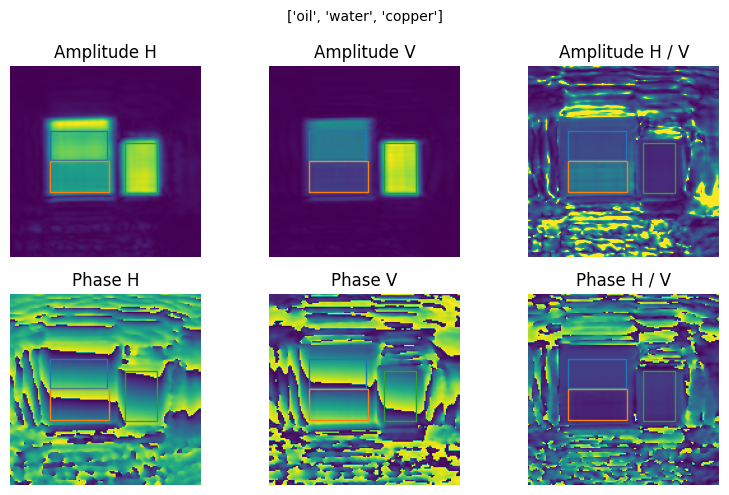

1tx, oil, water, copper


In [3]:
collection_list = [
    '20250603_185728_oil_water',
    '20250604_173925_soy',
    '20250605_123007_syrup',
    '20250605_163045_emptyglass',
    '20250605_194155_water',
    '20250606_132348_water_sugar_1sp',
    '20250606_162749_water_sugar_2sp',
    '20250606_212010_water_sugar_3sp',
    '20250607_160907_water_sugar_4sp',
    '20250609_101012_water_sugar_5sp',
    '20250609_130748_water_sugar_6sp',
]

data_config = {'sigma': 1, 'shrink_w': 5}
material_list = pol.load_materials_from_collection(
    collection_list, labels_dir=labels_dir, cfg_load=data_config)

# Preview first collection
label_dict, [sar_h, sar_v] = pol.load_sar_fromfile(
    collection_list[0], ['RH', 'RV'], labels_dir=labels_dir, cfg_load={'sigma': 1})
pol.visualize_labeled_sar(label_dict['labels'], sar_h, sar_v)
print(label_dict['description'])

## Polarization angle distribution (ECDF)

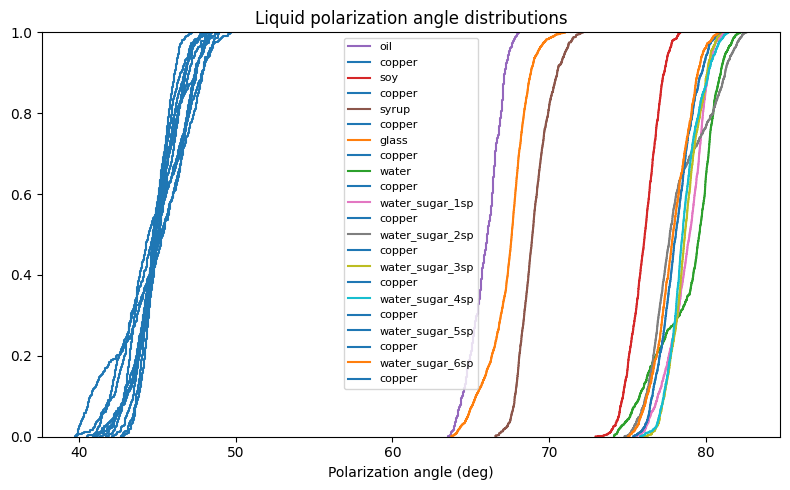

In [4]:
materials = [
    'copper', 'glass', 'water', 'soy', 'oil', 'syrup',
    'water_sugar_1sp', 'water_sugar_2sp', 'water_sugar_3sp',
    'water_sugar_4sp', 'water_sugar_5sp', 'water_sugar_6sp',
]
color_map = {m: c for m, c in zip(materials, cycle(color_list))}

AR = 0.1
result = {}

fig, ax = plt.subplots(figsize=(8, 5))
for mtrls_dict in material_list:
    ref = np.mean(np.abs(mtrls_dict['copper'][2]))
    for name, [sh, sv, div] in mtrls_dict.items():
        if name not in color_map:
            continue
        if name == 'glass' and len(mtrls_dict) > 2:
            continue
        if name == 'water' and 'oil' in mtrls_dict:
            continue

        temp = np.abs(div.ravel()) / ref
        theta = fresnel.remove_axial_ratio_2(temp, AR=AR) / np.pi * 180
        ref_angle = np.angle(np.mean(mtrls_dict['copper'][2]))
        result[name] = {
            'amplitude': theta,
            'angle': div.ravel() * np.exp(-1j * ref_angle),
        }
        ax.ecdf(theta, label=name, color=color_map[name])

ax.legend(fontsize=8)
ax.set_xlabel('Polarization angle (deg)')
ax.set_title('Liquid polarization angle distributions')
plt.tight_layout()
plt.show()

## Box plots: amplitude and phase

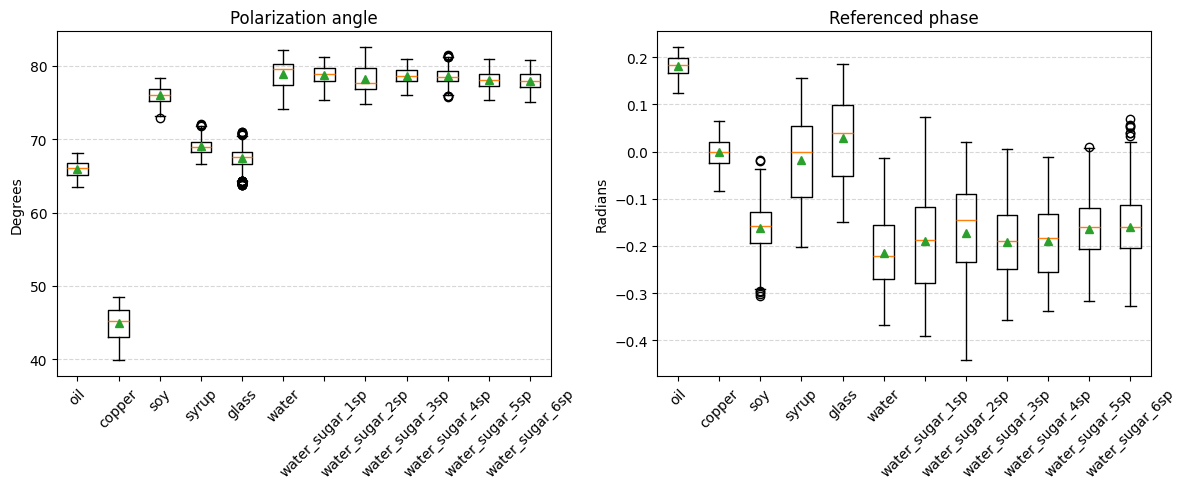

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(
    [x['amplitude'] for x in result.values()],
    labels=result.keys(), showmeans=True)
axes[0].set_title('Polarization angle')
axes[0].set_ylabel('Degrees')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

axes[1].boxplot(
    [np.angle(x['angle']) for x in result.values()],
    labels=result.keys(), showmeans=True)
axes[1].set_title('Referenced phase')
axes[1].set_ylabel('Radians')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Permittivity estimation

In [8]:
materials_dir = '../data/materials/'
pol_config = {'AR': 0.05, 'percentile_range': [30, 70]}

liquid_permittivity_list = []

for file_path in sorted(glob.glob(os.path.join(materials_dir, '*_55.pkl'))):
    with open(file_path, 'rb') as f:
        mat = pickle.load(f)

    polarization_angle, angle_refed = pol.calc_polarimetry(
        mat['values'][2], mat['ref_values'][2], config=pol_config)
    pol_val = np.tan(np.deg2rad(polarization_angle))
    eps = fresnel.ratio_to_epsilon(pol_val, mat['incident_angle'])
    eps_complex = fresnel.ratio_to_epsilon(
        pol_val * np.exp(-1j * np.angle(angle_refed)), mat['incident_angle'])

    liquid_permittivity_list.append({
        'name': mat['name'] + '_55',
        'permittivity': eps,
        'permittivity_complex': eps_complex,
        'pol_angle': polarization_angle,
        'div_val': angle_refed,
    })

# Display names for liquid materials
show_list = {
    'soy_55':              'Soy Sauce (w/ glass)',
    'oil_55':              'Corn Oil (w/ glass)',
    'syrup_55':            'Corn Syrup (w/ glass)',
    'water_55':            'Water (w/ glass)',
    'water_sugar_1sp_55':  'Sugar-water (1.3%, w/ glass)',
    'water_sugar_3sp_55':  'Sugar-water (5.1%, w/ glass)',
    'water_sugar_4sp_55':  'Sugar-water (6.3%, w/ glass)',
    'water_sugar_5sp_55':  'Sugar-water (7.4%, w/ glass)',
    'water_sugar_6sp_55':  'Sugar-water (10%, w/ glass)',
}

filtered_liquid_list = [
    x for key in show_list.keys()
    for x in liquid_permittivity_list
    if x['name'] == key
]

liquid_labels = [show_list[x['name']] for x in filtered_liquid_list]

print(f'{"Material":<35s} {"ε\'":<10s} {"−jε\"":<10s}')
print('-' * 55)
for x, label in zip(filtered_liquid_list, liquid_labels):
    eps_mean = np.mean(x['permittivity_complex'])
    print(f'{label:<35s} {eps_mean.real:<10.2f} {abs(eps_mean.imag):<10.2f}')

Material                            ε'         −jε"      
-------------------------------------------------------
Soy Sauce (w/ glass)                4.30       0.53      
Corn Oil (w/ glass)                 7.12       2.13      
Corn Syrup (w/ glass)               6.42       0.05      
Water (w/ glass)                    3.66       0.43      
Sugar-water (1.3%, w/ glass)        3.72       0.43      
Sugar-water (5.1%, w/ glass)        3.78       0.44      
Sugar-water (6.3%, w/ glass)        3.81       0.43      
Sugar-water (7.4%, w/ glass)        3.89       0.41      
Sugar-water (10%, w/ glass)         3.96       0.39      


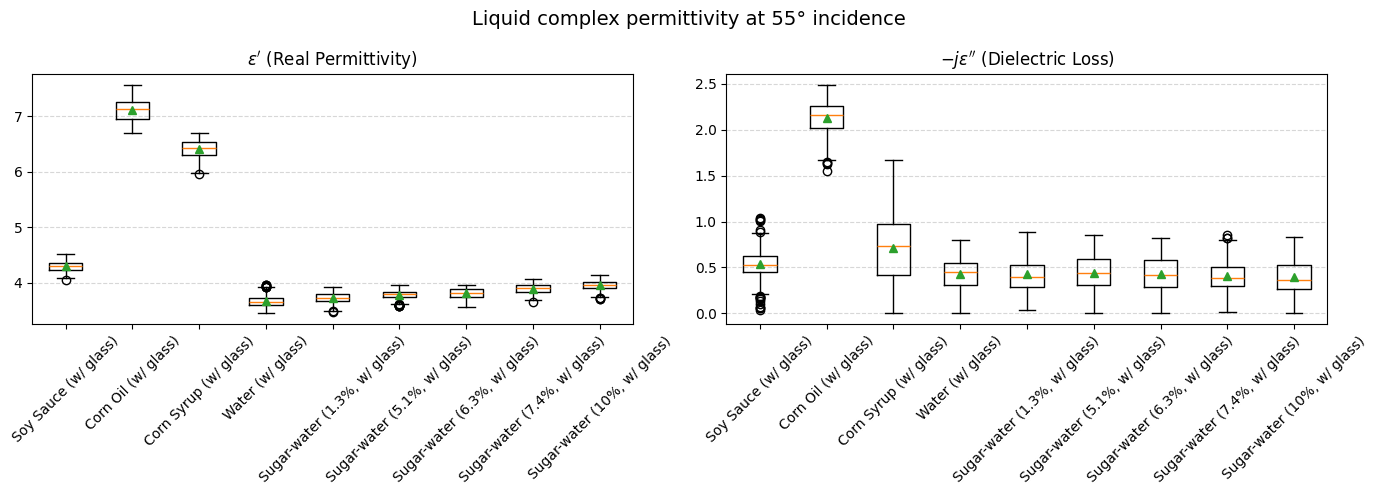

In [9]:
# Box plots: ε' and −jε'' for liquids
eps_arrays = [x['permittivity_complex'] for x in filtered_liquid_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([x.real.ravel() for x in eps_arrays], showmeans=True)
axes[0].set_title(r"$\epsilon'$ (Real Permittivity)")
axes[0].set_xticks(range(1, len(liquid_labels) + 1), liquid_labels)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

axes[1].boxplot([np.abs(x.imag).ravel() for x in eps_arrays], showmeans=True)
axes[1].set_title(r"$-j\epsilon''$ (Dielectric Loss)")
axes[1].set_xticks(range(1, len(liquid_labels) + 1), liquid_labels)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

fig.suptitle('Liquid complex permittivity at 55° incidence', fontsize=14)
plt.tight_layout()
plt.show()